# EDA de Afluencia del Metro de la Ciudad de México de 2010 a 2025

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Dataframe histórico de 2010 a 2025
url = 'https://github.com/AndrsGzRo/prediccion-afluencia-metrocdmx/raw/refs/heads/main/Data/processed/afluencia_metro_2010_2025.zip'
df = pd.read_csv(url,compression='zip')
df.tail()

,fecha,anio,linea,estacion,afluencia,mes_num,mes_nom
1139544,2025-12-31,2025,Línea B,Romero Rubio,10938,12,diciembre
1139545,2025-12-31,2025,Línea B,Río de los Remedios,10559,12,diciembre
1139546,2025-12-31,2025,Línea B,San Lázaro,10453,12,diciembre
1139547,2025-12-31,2025,Línea B,Tepito,18457,12,diciembre
1139548,2025-12-31,2025,Línea B,Villa de Aragón,5796,12,diciembre


In [3]:
df['fecha'] = pd.to_datetime(df['fecha'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1139549 entries, 0 to 1139548
Data columns (total 7 columns):
 #   Column     Non-Null Count    Dtype         
---  ------     --------------    -----         
 0   fecha      1139549 non-null  datetime64[ns]
 1   anio       1139549 non-null  int64         
 2   linea      1139549 non-null  object        
 3   estacion   1139549 non-null  object        
 4   afluencia  1139549 non-null  int64         
 5   mes_num    1139549 non-null  int64         
 6   mes_nom    1139549 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 60.9+ MB


### Normalización de la Afluencia

In [4]:
# Normalización de afluencia
df['afluencia_norm'] = (
    df['afluencia']/df.groupby('linea')['afluencia'].transform('mean')
)

In [5]:
df.head()

,fecha,anio,linea,estacion,afluencia,mes_num,mes_nom,afluencia_norm
0,2010-01-01,2010,Línea 1,Zaragoza,20227,1,enero,0.740833
1,2010-01-01,2010,Línea 1,Isabel la Católica,6487,1,enero,0.237592
2,2010-01-01,2010,Línea 1,Moctezuma,10304,1,enero,0.377394
3,2010-01-01,2010,Línea 1,Pino Suárez,8679,1,enero,0.317876
4,2010-01-01,2010,Línea 1,Gómez Farías,19499,1,enero,0.714169


## Evolución de la Afluencia

In [6]:
sns.set_theme(style='darkgrid')
metro_color = '#FE5000'
colores_metro = {
    'Línea 1':'#F04E98',
    'Línea 2':'#005EB8',
    'Línea 3':'#AF9800',
    'Línea 4':'#6BBBAE',
    'Línea 5':'#FFD100',
    'Línea 6':'#DA291C',
    'Línea 7':'#E87722',
    'Línea 8':'#009444',
    'Línea 9':'#512F2E',
    'Línea A':'#981D97',
    'Línea B':'#B1B3B3',
    'Línea 12':'#B0A32A'
}


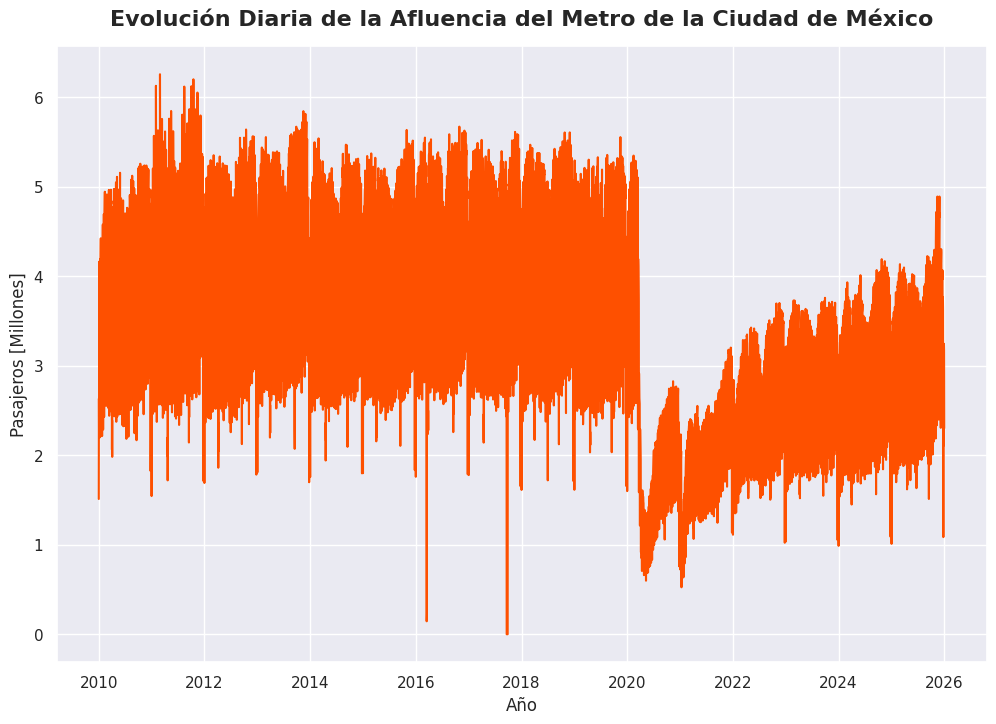

In [7]:
afluencia_fecha = (
    df.groupby('fecha')['afluencia'].sum().reset_index()
)
afluencia_fecha['afluencia_mill'] = afluencia_fecha['afluencia']/1e6

# Visualización

plt.figure(figsize=(12,8))
sns.lineplot(
    data=afluencia_fecha,
    x='fecha',
    y='afluencia_mill',
    color=metro_color
)
plt.xlabel('Año')
plt.ylabel('Pasajeros [Millones]')
plt.title('Evolución Diaria de la Afluencia del Metro de la Ciudad de México',
          fontsize=16,fontweight='bold',pad=15)
plt.show()


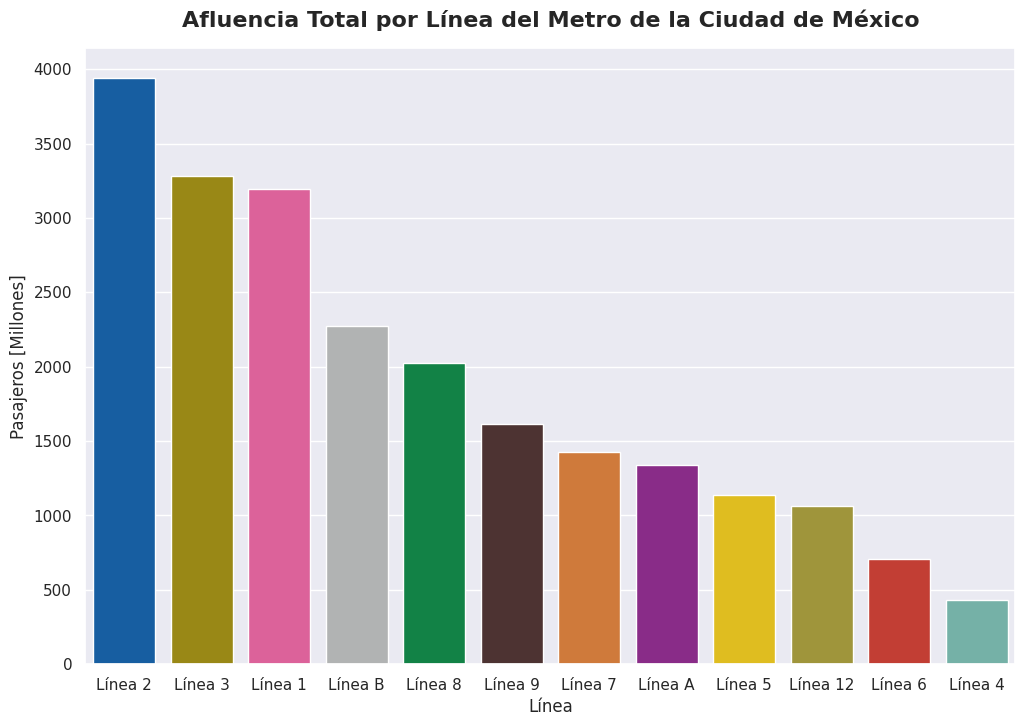

In [8]:
afluencia_linea = (
    df.groupby('linea')['afluencia'].sum().sort_values(ascending=False).reset_index()
)
afluencia_linea['afluencia_mill'] = afluencia_linea['afluencia']/1e6

# Visualización
plt.figure(figsize=(12,8))
sns.barplot(
    data=afluencia_linea,
    x='linea',
    y='afluencia_mill',
    palette=colores_metro,
    hue='linea'
)
plt.xlabel('Línea')
plt.ylabel('Pasajeros [Millones]')
plt.title('Afluencia Total por Línea del Metro de la Ciudad de México',
          fontsize=16,fontweight='bold',pad=15)
plt.show()

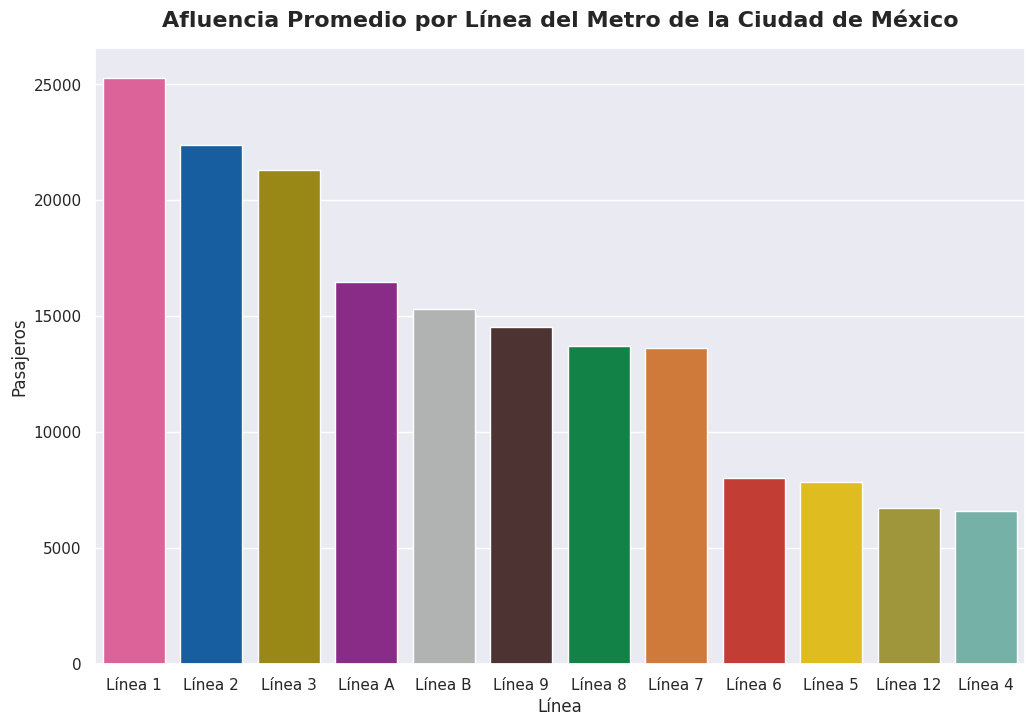

In [9]:
afluencia_prom_linea = (
    df.groupby('linea')['afluencia'].median().sort_values(ascending=False).reset_index()
)

# Visualización
plt.figure(figsize=(12,8))
sns.barplot(
    data=afluencia_prom_linea,
    x='linea',
    y='afluencia',
    palette=colores_metro,
    hue='linea'
)
plt.xlabel('Línea')
plt.ylabel('Pasajeros')
plt.title('Afluencia Promedio por Línea del Metro de la Ciudad de México',
          fontsize=16,fontweight='bold',pad=15)
plt.show()

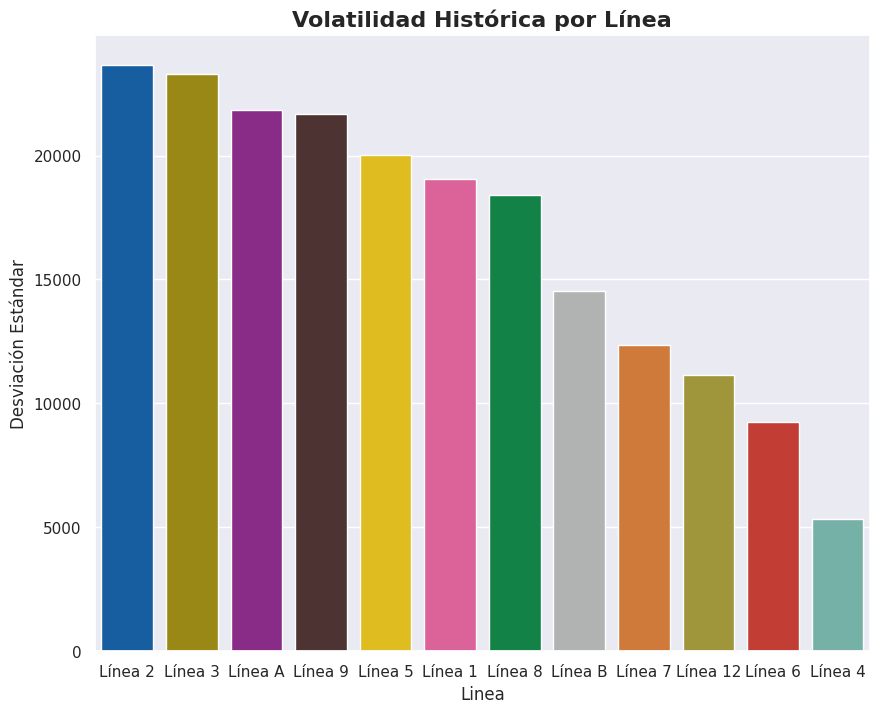

In [10]:
volatilidad = (
    df.groupby('linea')['afluencia']
    .std()
    .sort_values(ascending=False)
    .reset_index()
)
plt.figure(figsize=(10,8))
sns.barplot(
    data=volatilidad,
    x='linea',
    y='afluencia',
    palette=colores_metro,
    hue='linea'
)
plt.xlabel('Linea')
plt.ylabel('Desviación Estándar')
plt.title('Volatilidad Histórica por Línea',fontsize=16,fontweight='bold')
plt.show()

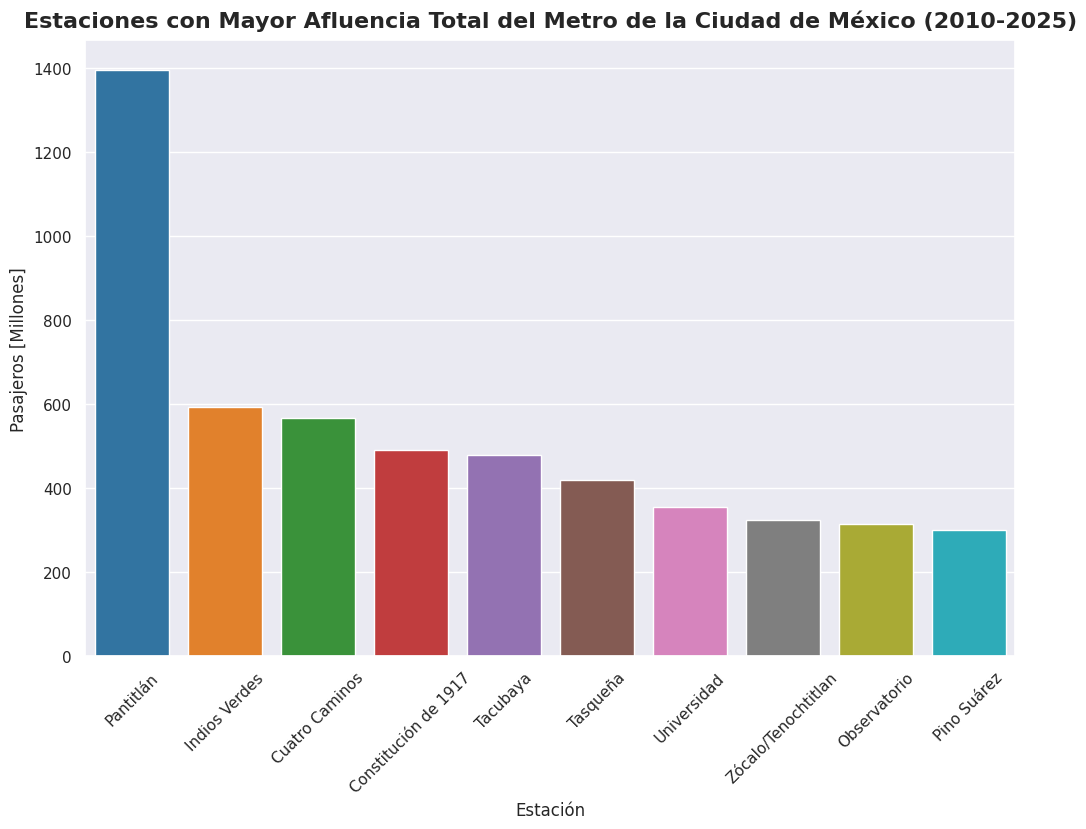

In [11]:
top10_estaciones = (
    df.groupby('estacion')['afluencia'].sum()
    .reset_index().sort_values('afluencia',ascending=False)
    .head(10)
)
7
top10_estaciones['afluencia_mill'] = top10_estaciones['afluencia']/1e6
plt.figure(figsize=(12,8))
sns.barplot(
    data = top10_estaciones,
    x='estacion',
    y='afluencia_mill',
    palette='tab10',
    hue='estacion'
)
plt.xlabel('Estación')
plt.xticks(rotation=45)
plt.ylabel('Pasajeros [Millones]')
plt.title('Estaciones con Mayor Afluencia Total del Metro de la Ciudad de México (2010-2025)',
          fontweight='bold',fontsize=16,pad=10)
plt.show()

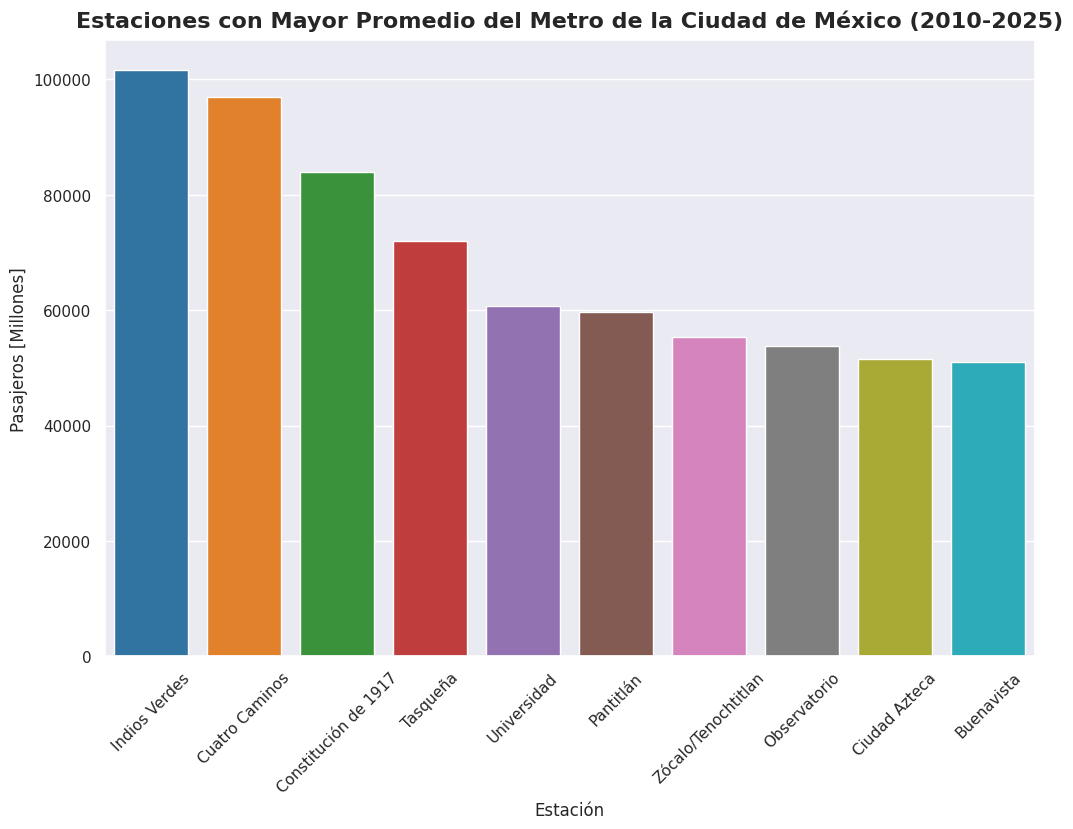

In [12]:
top10_estaciones_prom = (
    df.groupby('estacion')['afluencia'].mean()
    .reset_index().sort_values('afluencia',ascending=False)
    .head(10)
)
7
plt.figure(figsize=(12,8))
sns.barplot(
    data = top10_estaciones_prom,
    x='estacion',
    y='afluencia',
    palette='tab10',
    hue='estacion'
)
plt.xlabel('Estación')
plt.xticks(rotation=45)
plt.ylabel('Pasajeros [Millones]')
plt.title('Estaciones con Mayor Promedio del Metro de la Ciudad de México (2010-2025)',
          fontweight='bold',fontsize=16,pad=10)
plt.show()

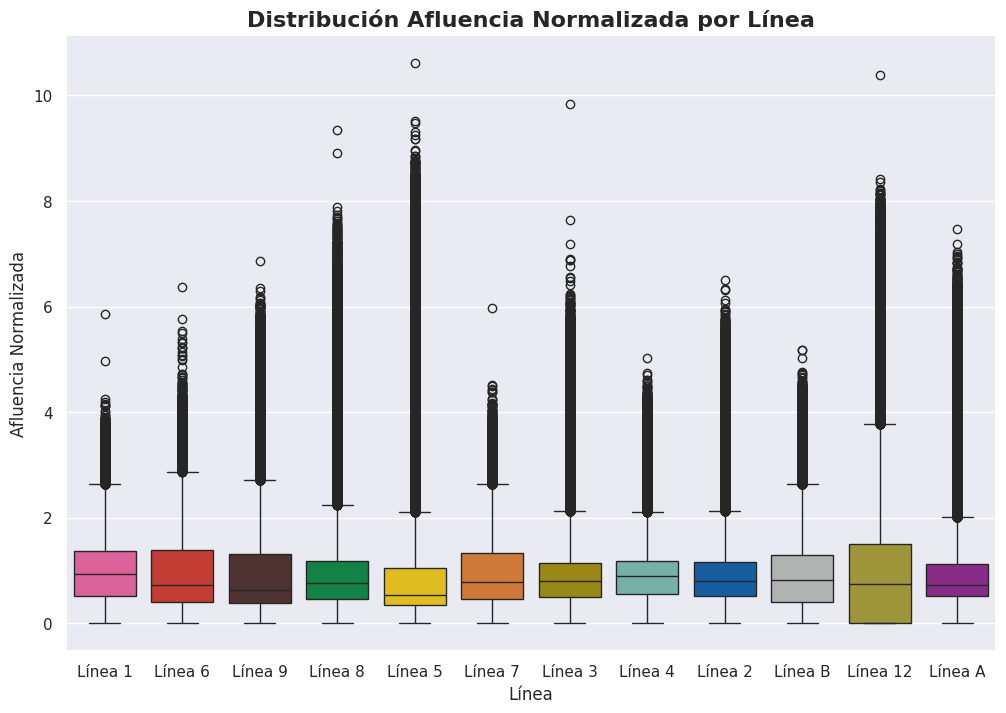

In [13]:
plt.figure(figsize=(12,8))
sns.boxplot(
    data=df,
    x='linea',
    y='afluencia_norm',
    palette=colores_metro,
    hue='linea',
    showfliers=True
)
plt.xlabel("Línea")
plt.ylabel("Afluencia Normalizada")
plt.title("Distribución Afluencia Normalizada por Línea",fontsize=16,
          fontweight='bold')
plt.show()

In [14]:
# Orden mes
orden_meses = [
    'enero','febrero','marzo','abril','mayo','junio',
    'julio','agosto','septiembre','octubre','noviembre','diciembre'
]

df['mes_nom'] = pd.Categorical(
    df['mes_nom'],
    categories=orden_meses,
    ordered=True
)

/tmp/ipython-input-754034237.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['linea','mes_nom'])['afluencia_norm']


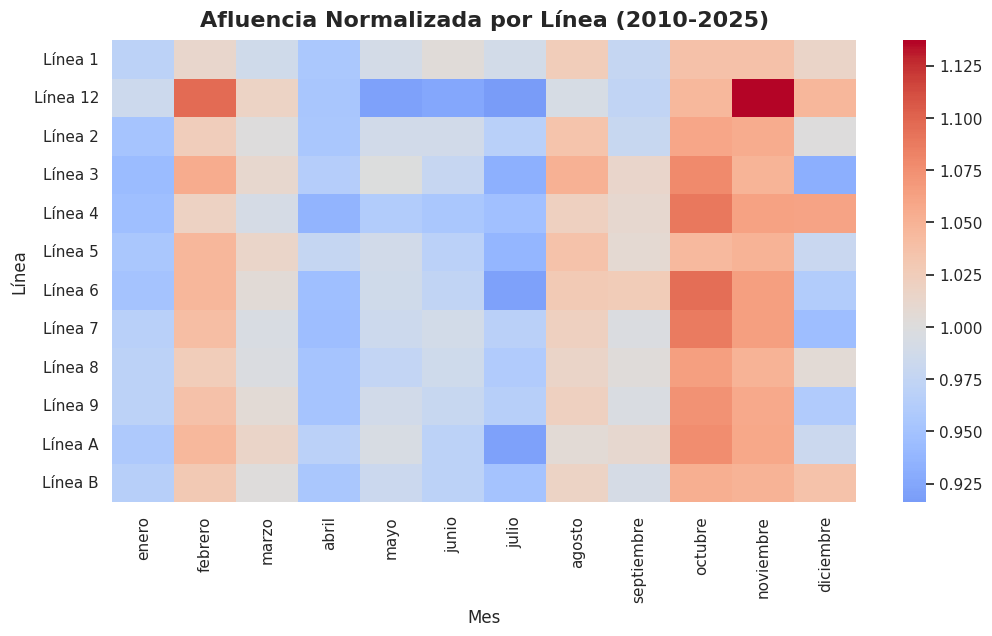

In [15]:
linea_heat = (
    df.groupby(['linea','mes_nom'])['afluencia_norm']
    .mean()
    .reset_index()
    .pivot(index='linea', columns='mes_nom', values='afluencia_norm')
)

plt.figure(figsize=(12,6))
sns.heatmap(linea_heat, cmap='coolwarm', center=1)
plt.xlabel('Mes')
plt.ylabel('Línea')
plt.title('Afluencia Normalizada por Línea (2010-2025)',fontsize=16,
          fontweight='bold',pad=10)
plt.show()


/tmp/ipython-input-1342641110.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['estacion','mes_nom'])['afluencia_norm']


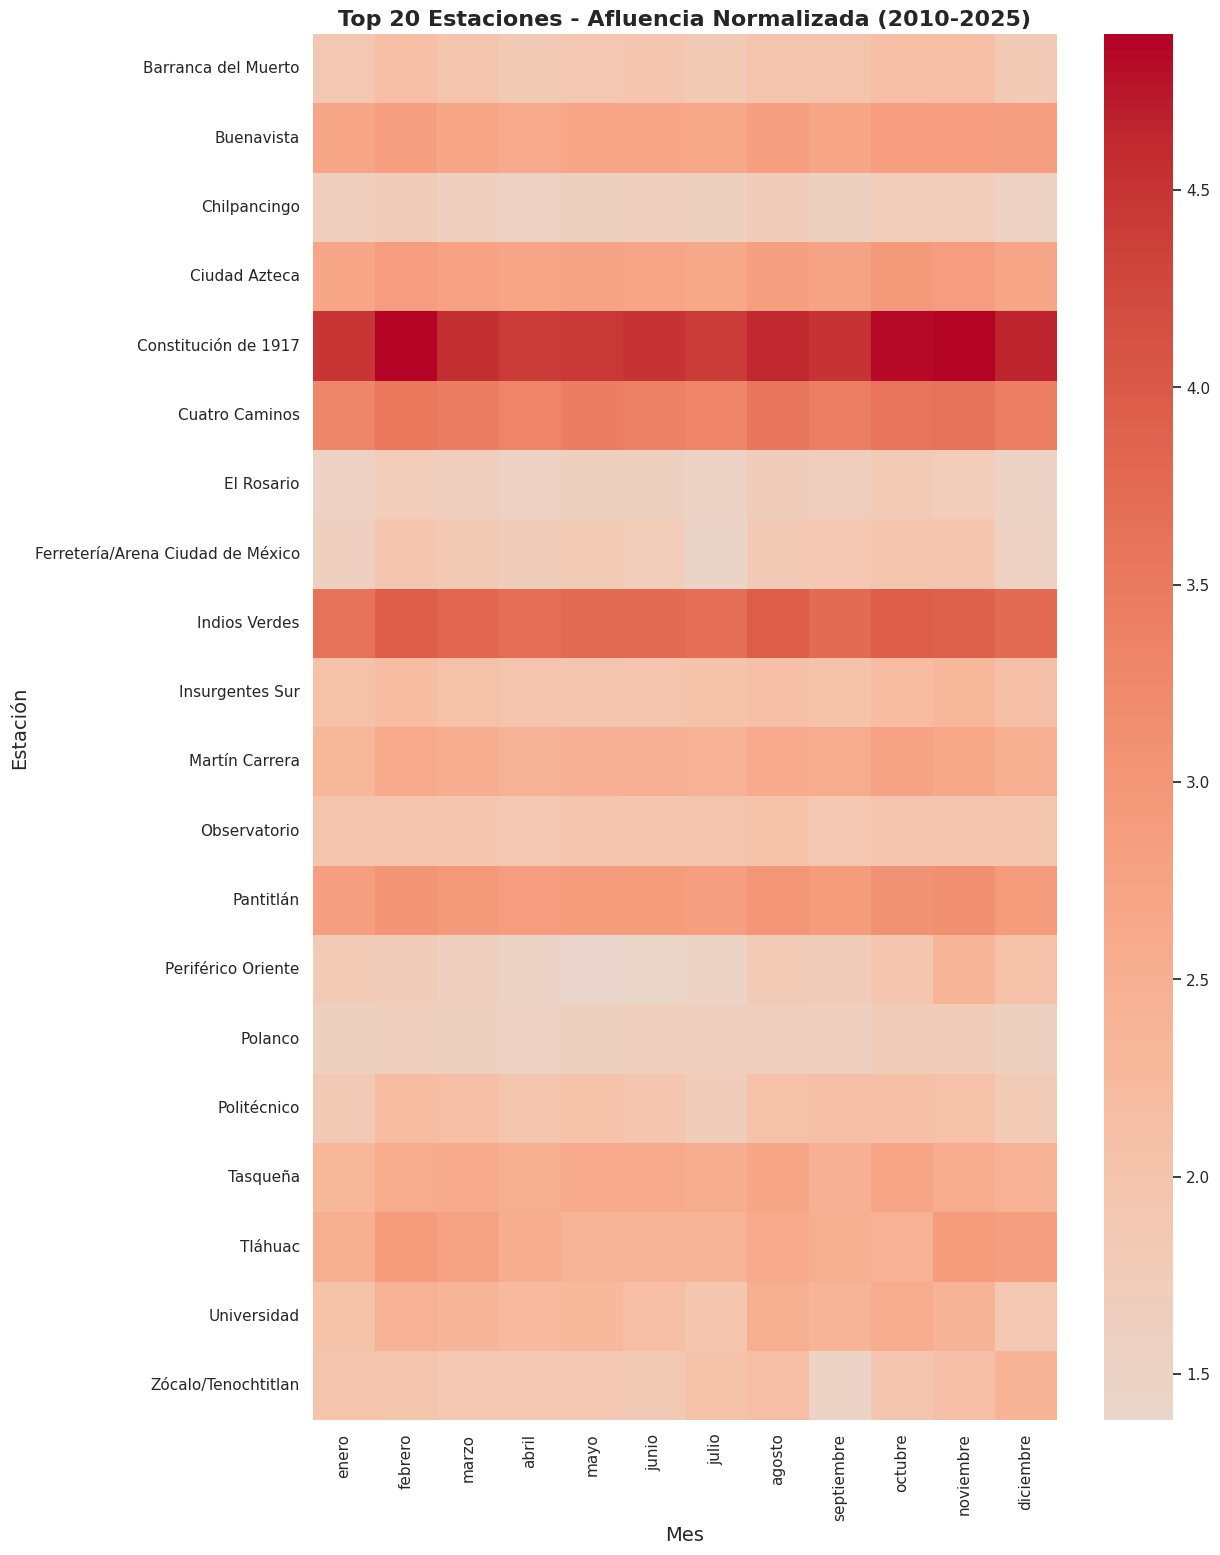

In [16]:
top20_est = (
    df.groupby('estacion')['afluencia_norm'].mean()
    .sort_values(ascending=False)
    .head(20)
    .index
)
heatmap_data = (
    df[df['estacion'].isin(top20_est)]
    .groupby(['estacion','mes_nom'])['afluencia_norm']
    .mean().reset_index()
    .pivot(index='estacion',columns='mes_nom',values='afluencia_norm'))

plt.figure(figsize=(12,18))
sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    center=1)
plt.xlabel('Mes',fontsize=14)
plt.ylabel('Estación',fontsize=14)
plt.title('Top 20 Estaciones - Afluencia Normalizada (2010-2025)',fontsize=16,
          fontweight='bold')
plt.show()

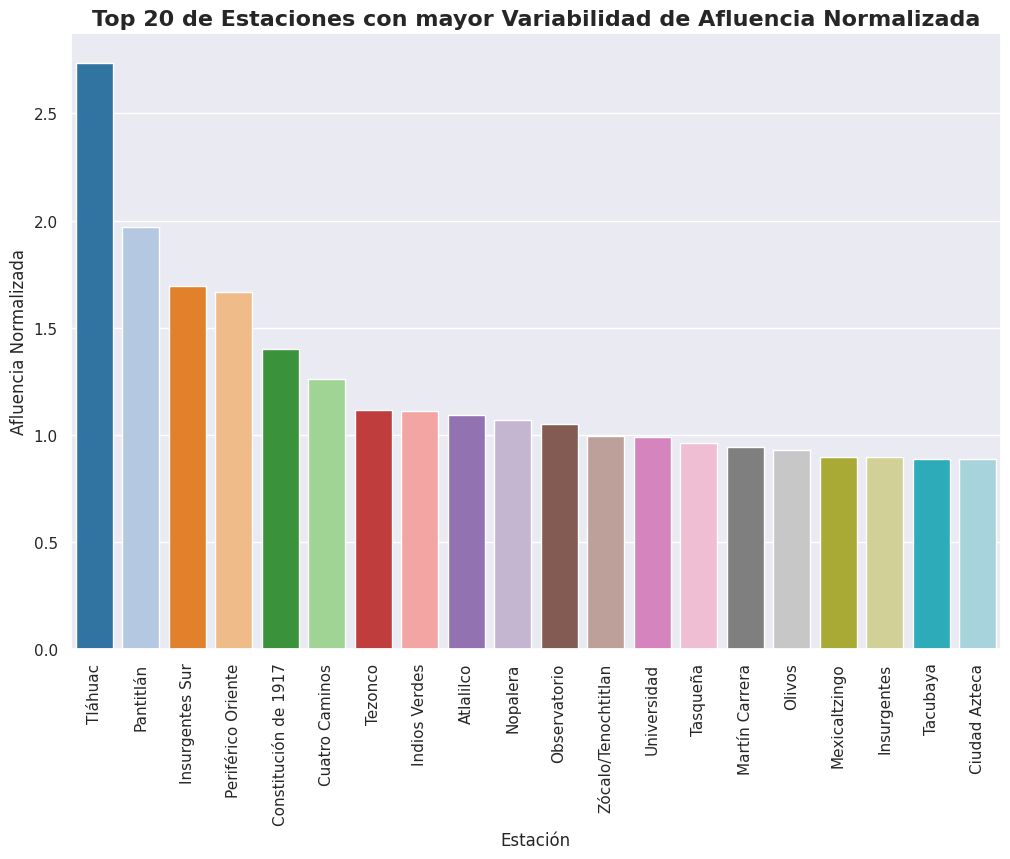

In [17]:
variabilidad_estacion_norm = (
    df.groupby('estacion')['afluencia_norm']
    .std()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
plt.figure(figsize=(12,8))
sns.barplot(
    data=variabilidad_estacion_norm,
    x='estacion',
    y='afluencia_norm',
    palette='tab20',
    hue='estacion'
)
plt.xlabel('Estación')
plt.xticks(rotation=90)
plt.ylabel('Afluencia Normalizada')
plt.title('Top 20 de Estaciones con mayor Variabilidad de Afluencia Normalizada',
          fontsize=16,fontweight='bold')
plt.show()

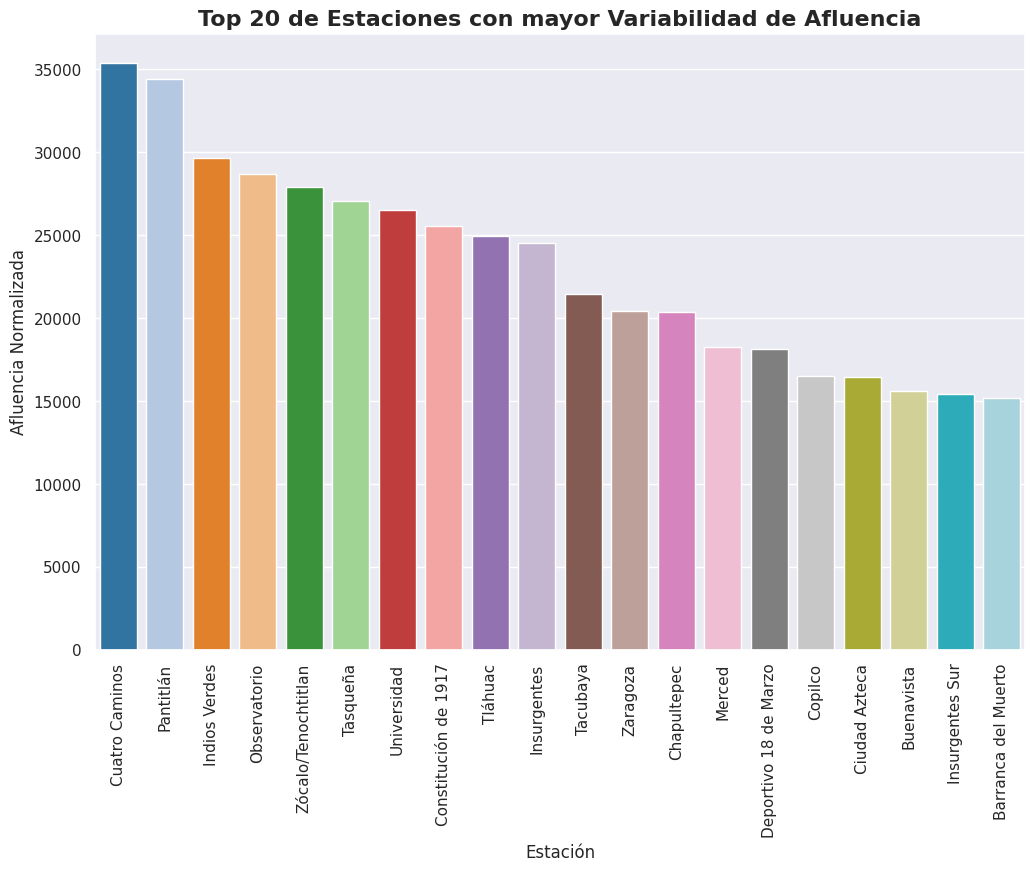

In [18]:
variabilidad_estacion = (
    df.groupby('estacion')['afluencia']
    .std()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
plt.figure(figsize=(12,8))
sns.barplot(
    data=variabilidad_estacion,
    x='estacion',
    y='afluencia',
    palette='tab20',
    hue='estacion'
)
plt.xlabel('Estación')
plt.xticks(rotation=90)
plt.ylabel('Afluencia Normalizada')
plt.title('Top 20 de Estaciones con mayor Variabilidad de Afluencia',
          fontsize=16,fontweight='bold')
plt.show()

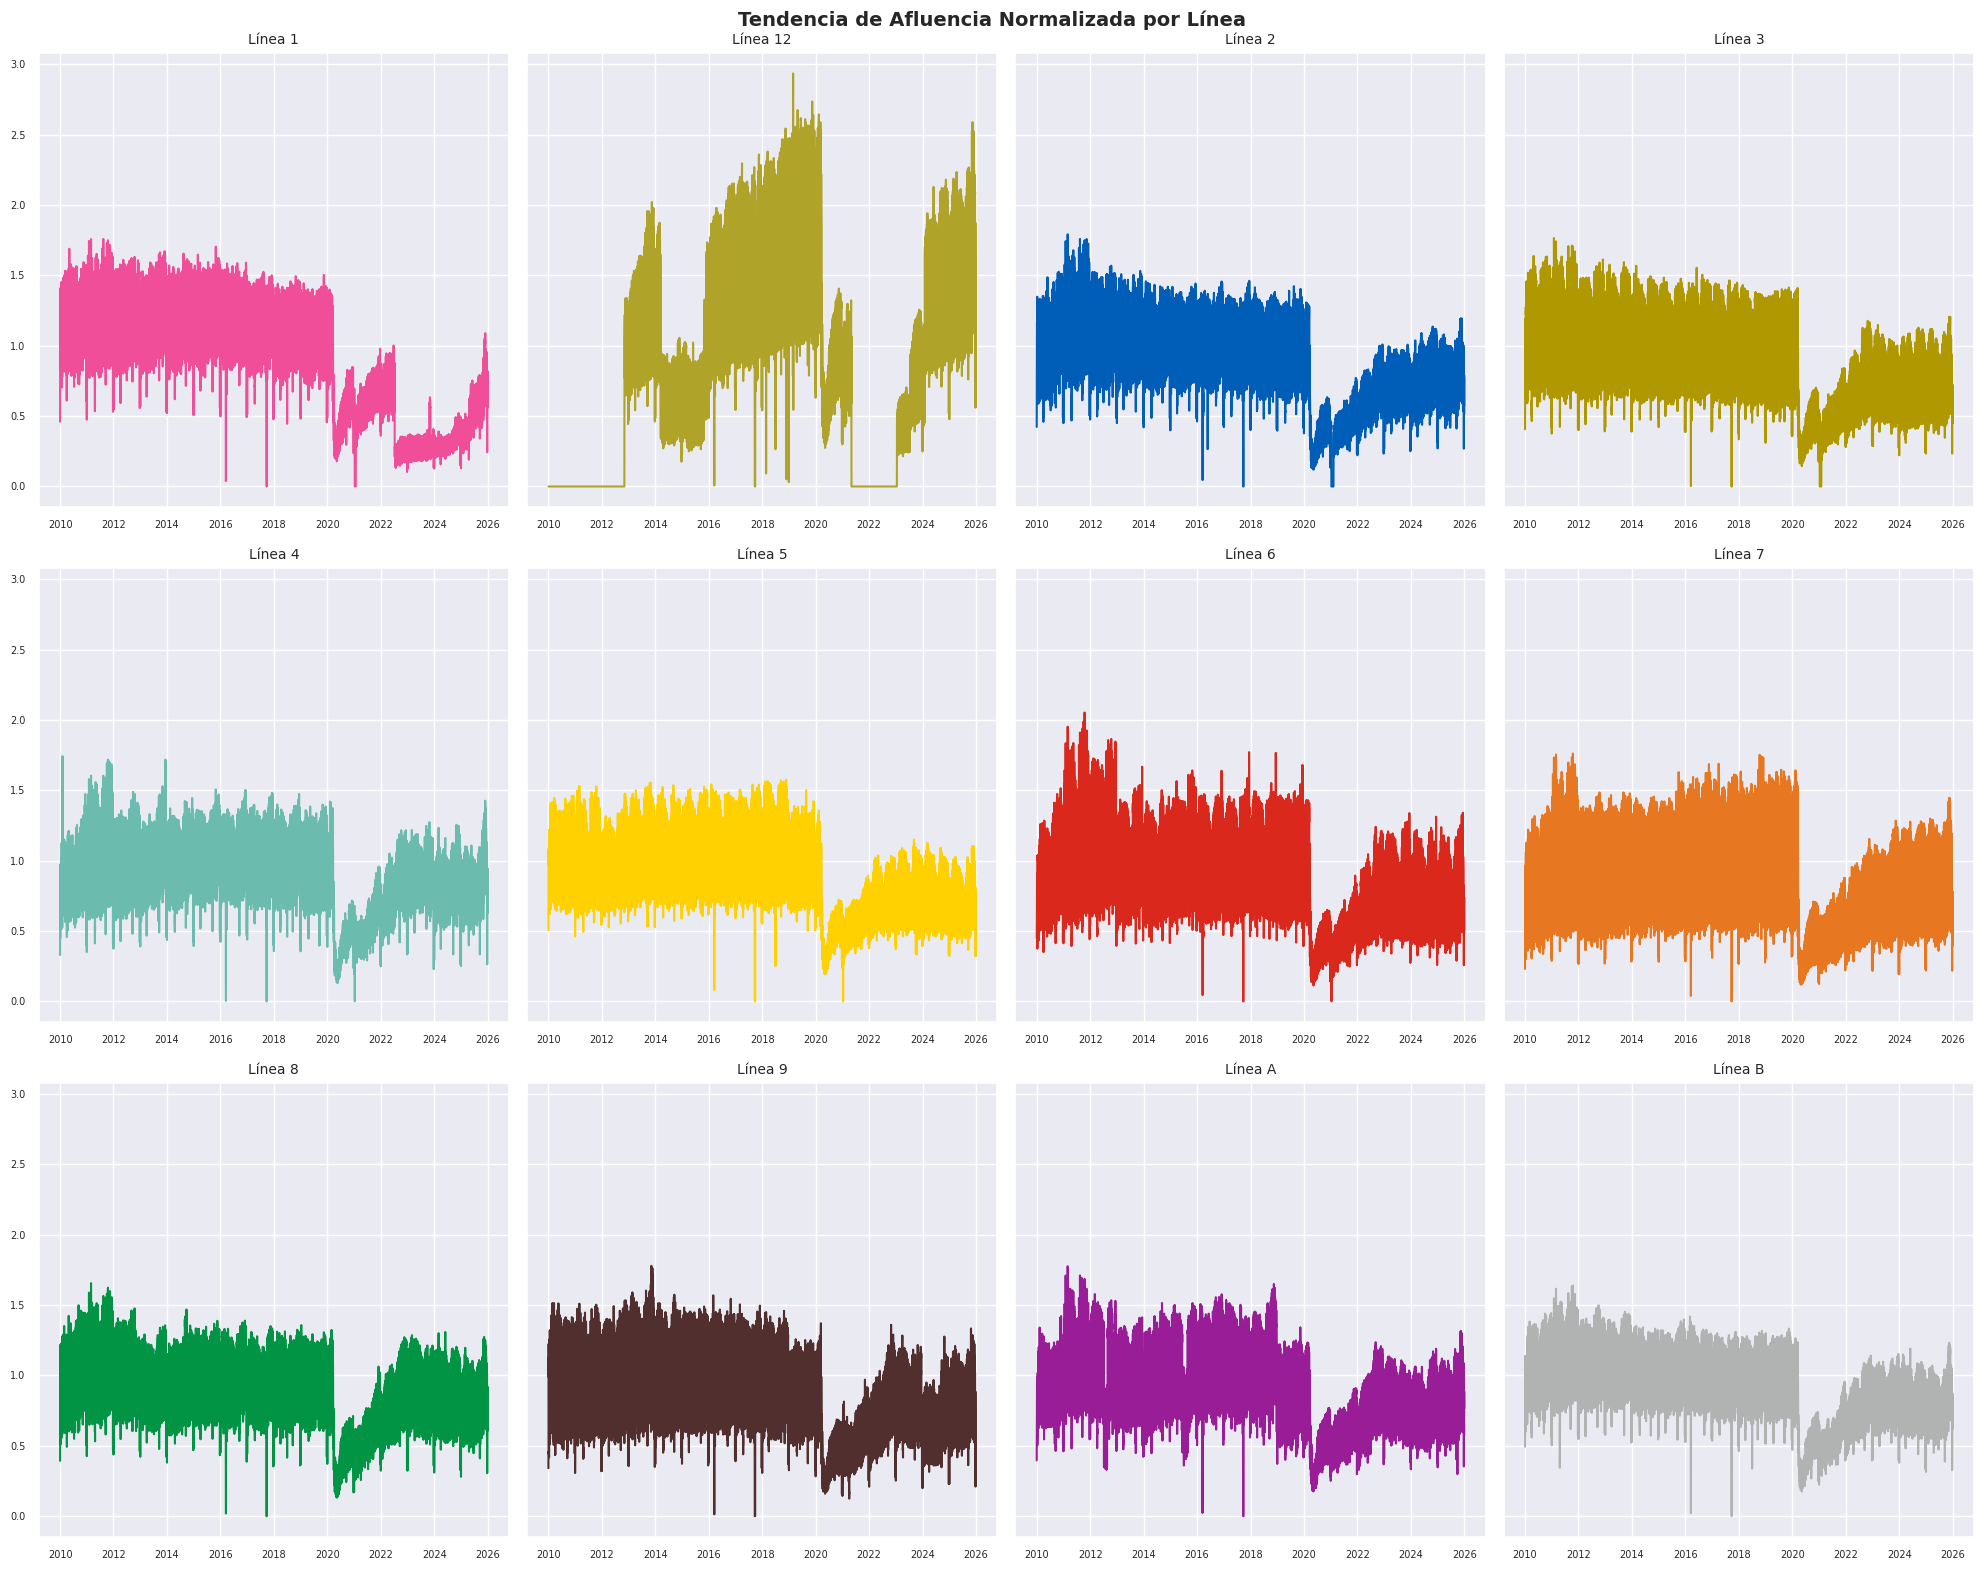

In [19]:
linea_tiempo = (
    df.groupby(['fecha','linea'])['afluencia_norm']
    .mean()
    .reset_index()
)

lineas = sorted(linea_tiempo['linea'].unique())
n_lineas = len(lineas)
n_cols = 4
n_rows = int(np.ceil(n_lineas/n_cols))

fig, axes = plt.subplots(
    n_rows,n_cols,
    figsize=(20,16),
    sharex=False,sharey=True)

axes = np.array(axes).reshape(-1)

for i,linea in enumerate(lineas):
    subset = linea_tiempo[linea_tiempo['linea'] == linea]
    axes[i].plot(subset['fecha'],subset['afluencia_norm'],color=colores_metro[linea])
    axes[i].set_title(f'{linea}',fontsize=10)
    axes[i].tick_params(labelsize=7)

for j in range(i+1,len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Tendencia de Afluencia Normalizada por Línea",
             fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()


## Comparación Pre-Pandemia y Post-Pandemia

In [20]:
df['periodo'] = 'pandemia'

# Pre-pandemia (Antes de 2020)
df.loc[df['anio'] <= 2019,'periodo'] = 'pre'
# Post-pandemia (2022 en adelante)
df.loc[df['anio'] >=2022, 'periodo'] = 'post'

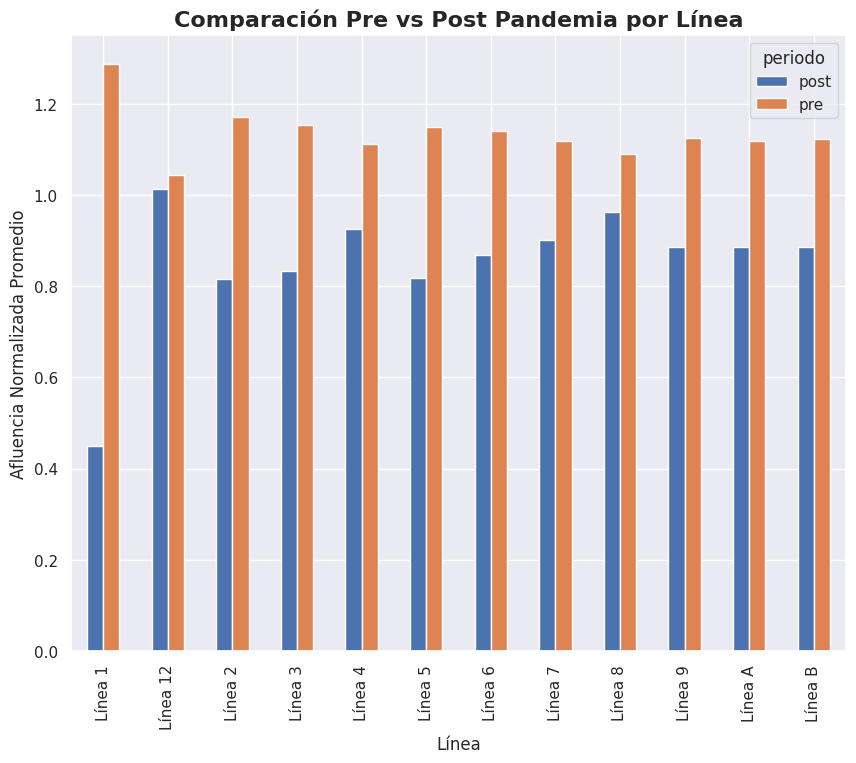

In [21]:
comparacion_linea = (
    df[df['periodo'] !='pandemia']
    .groupby(['linea','periodo'])['afluencia_norm']
    .mean()
    .unstack()
)
comparacion_linea.plot(kind='bar',figsize=(10,8))
plt.xlabel('Línea')
plt.ylabel('Afluencia Normalizada Promedio')
plt.title('Comparación Pre vs Post Pandemia por Línea',fontsize=16,fontweight='bold')
plt.show()

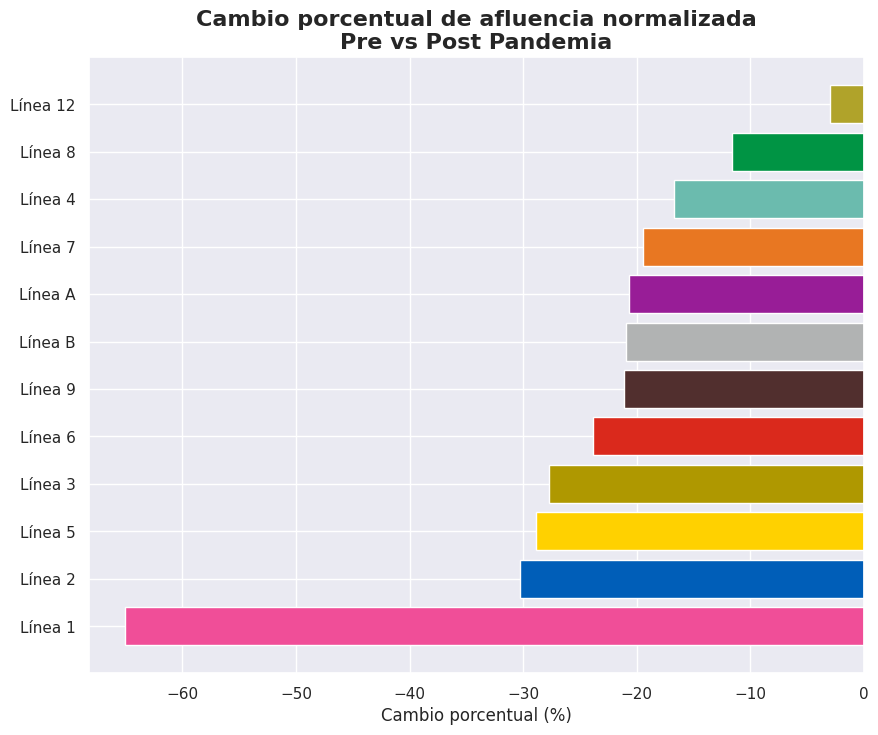

In [22]:
# Cambio porcentual
comparacion_linea['cambio_%'] = (
    (comparacion_linea['post'] - comparacion_linea['pre'])/comparacion_linea['pre']
)*100
comparacion_linea = comparacion_linea.sort_values('cambio_%',ascending=True)

# Colores Metro
colores_ordenados = [
    colores_metro[linea]
    for linea in comparacion_linea.index
]
plt.figure(figsize=(10,8))
plt.barh(
    comparacion_linea.index,
    comparacion_linea['cambio_%'],
    color=colores_ordenados
)
plt.xlabel("Cambio porcentual (%)")
plt.title("Cambio porcentual de afluencia normalizada\nPre vs Post Pandemia",
          fontsize=16,fontweight='bold')

plt.show()

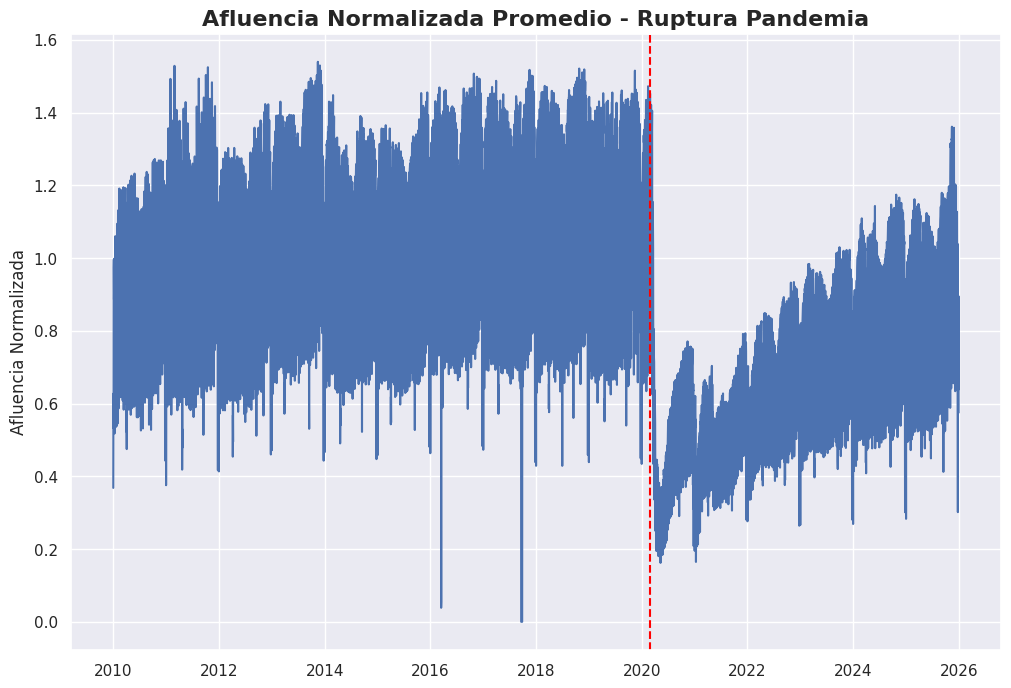

In [23]:
global_mensual = (
    df.groupby('fecha')['afluencia_norm']
    .mean()
)
plt.figure(figsize=(12,8))
plt.plot(global_mensual.index,global_mensual.values)
plt.axvline(pd.to_datetime('2020-03-01'),color='red',linestyle='--')
plt.ylabel('Afluencia Normalizada')
plt.title('Afluencia Normalizada Promedio - Ruptura Pandemia',fontsize=16,
          fontweight='bold')
plt.show()

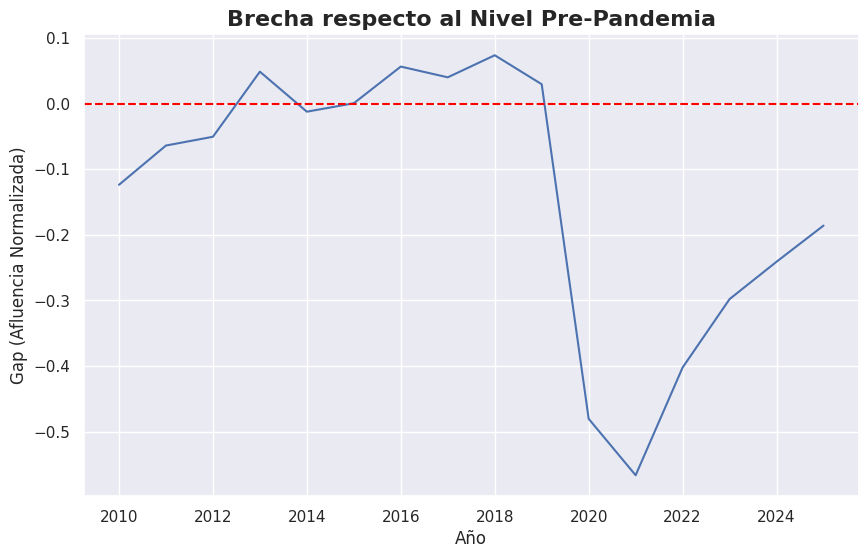

In [24]:
baseline = (
    df[df['anio'] <=2019]
    .groupby('linea')['afluencia_norm']
    .mean()
)
df['gap'] = (
    df['afluencia_norm'] - df['linea'].map(baseline))

gap_anual = (
    df
    .groupby(['anio','linea'])['gap']
    .mean()
    .reset_index()
)

gap_global = (
    gap_anual
    .groupby('anio')['gap']
    .mean()
)
plt.figure(figsize=(10,6))
plt.plot(gap_global.index,gap_global.values)
plt.axhline(0,color='red',linestyle='--')
plt.xlabel('Año')
plt.ylabel('Gap (Afluencia Normalizada)')
plt.title('Brecha respecto al Nivel Pre-Pandemia',fontsize=16,fontweight='bold')
plt.show()

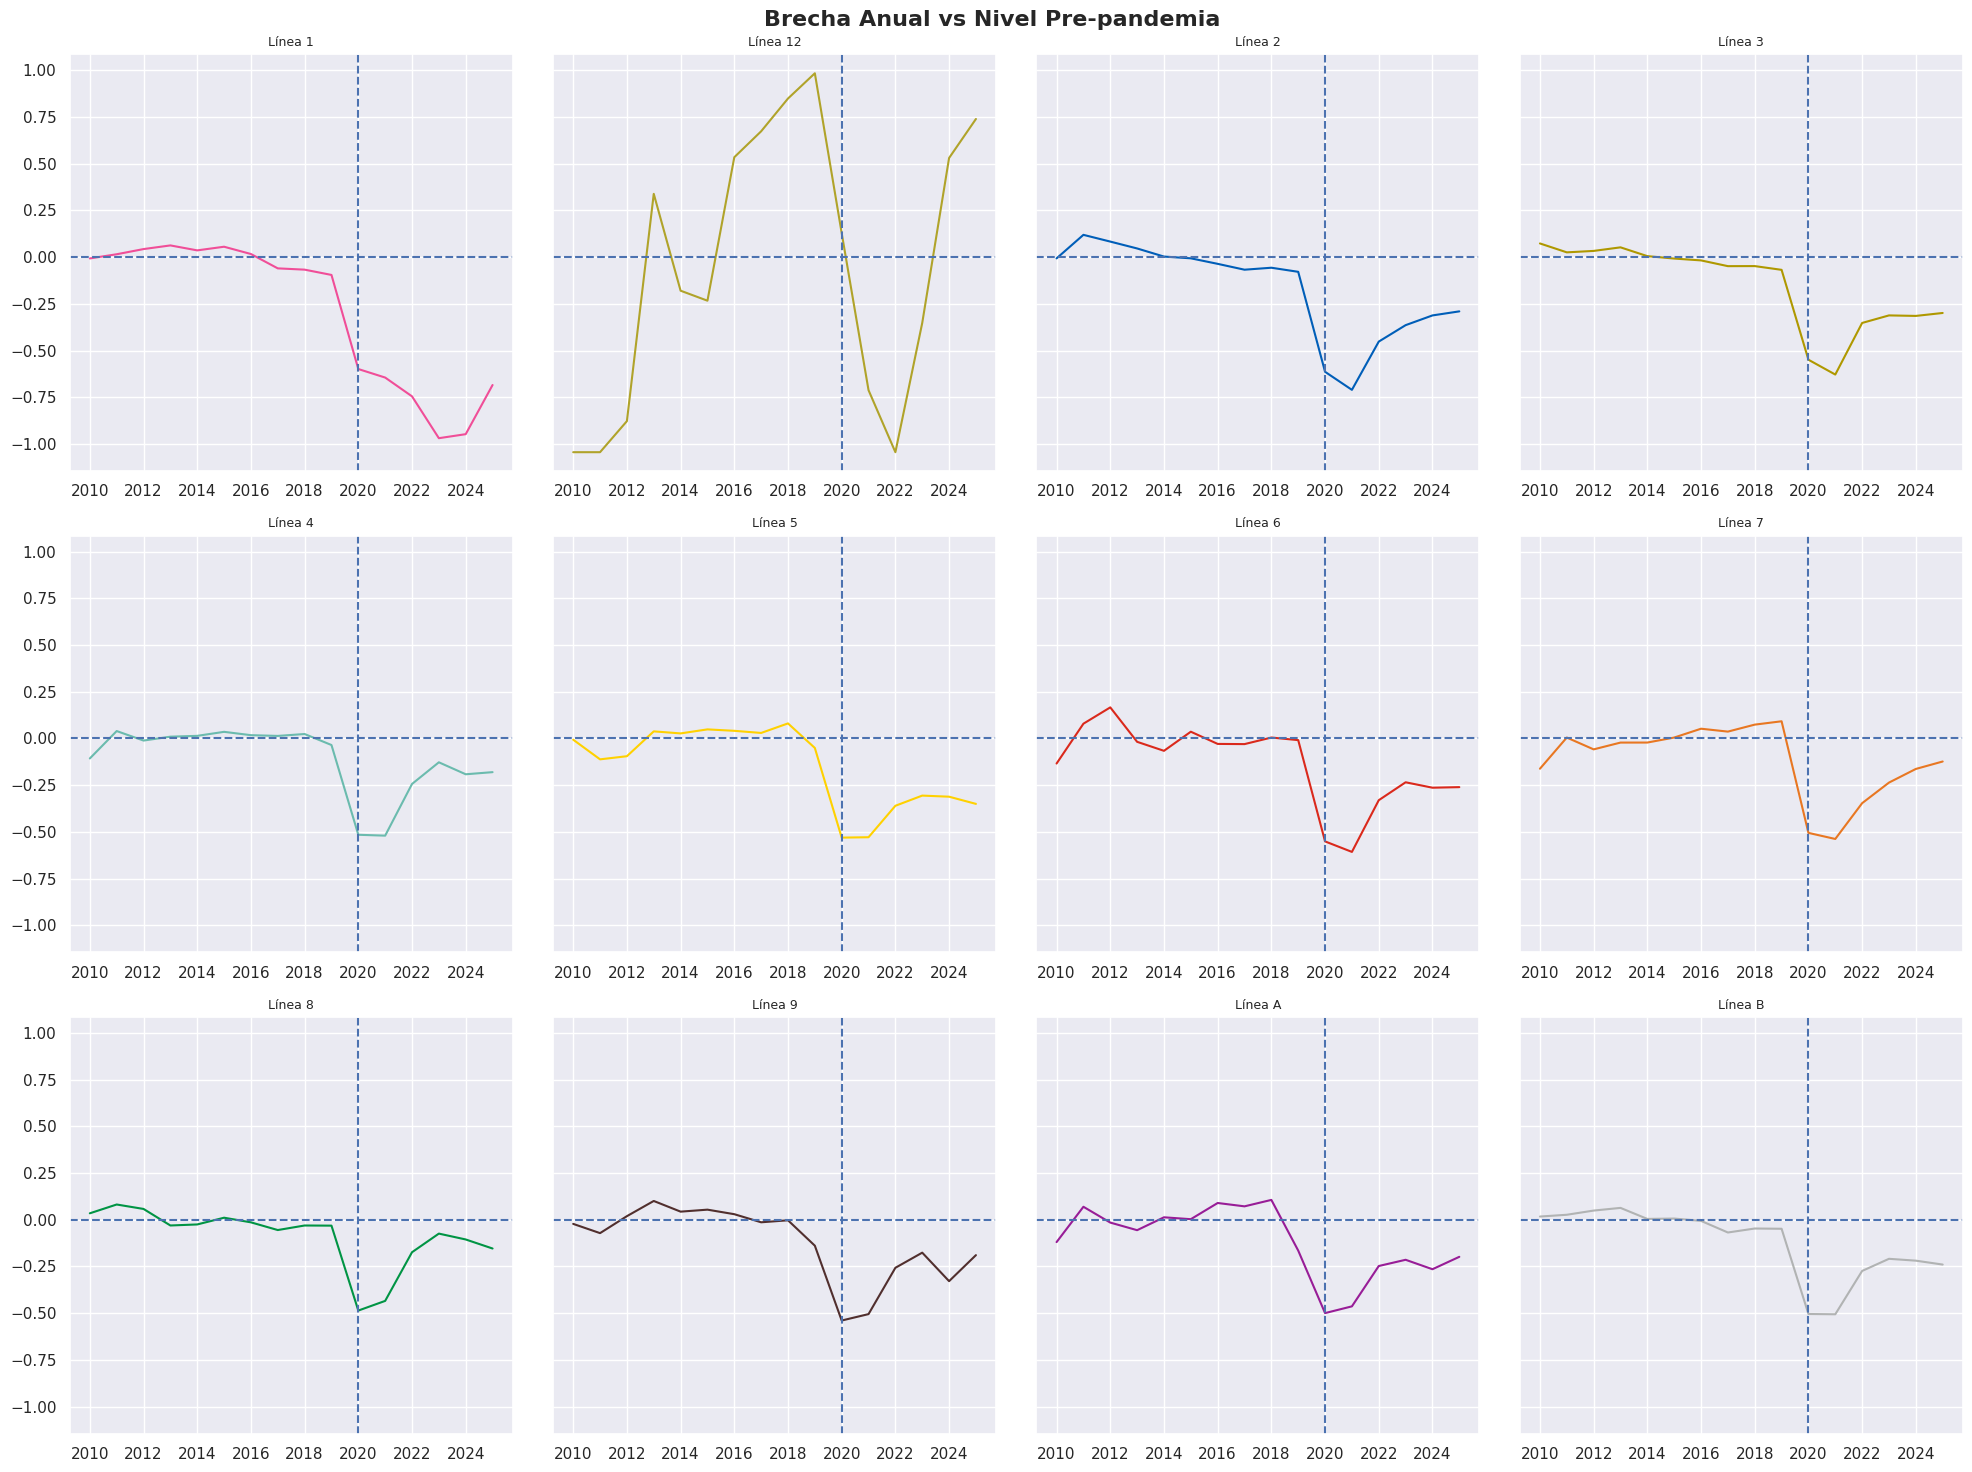

In [25]:
lineas = sorted(gap_anual['linea'].unique())
n_cols = 4
n_rows = int(np.ceil(len(lineas)/n_cols))

fig,axes = plt.subplots(n_rows,n_cols,figsize=(20,15),sharex=False,sharey=True)
axes = np.array(axes).reshape(-1)
for i,linea in enumerate(lineas):
    subset = gap_anual[gap_anual['linea'] == linea]
    axes[i].plot(subset['anio'], subset['gap'],color=colores_metro[linea])
    axes[i].axhline(0, linestyle='--')
    axes[i].axvline(2020, linestyle='--')
    axes[i].set_title(linea, fontsize=9)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Brecha Anual vs Nivel Pre-pandemia",fontsize=16,fontweight='bold')
plt.tight_layout()
plt.show()

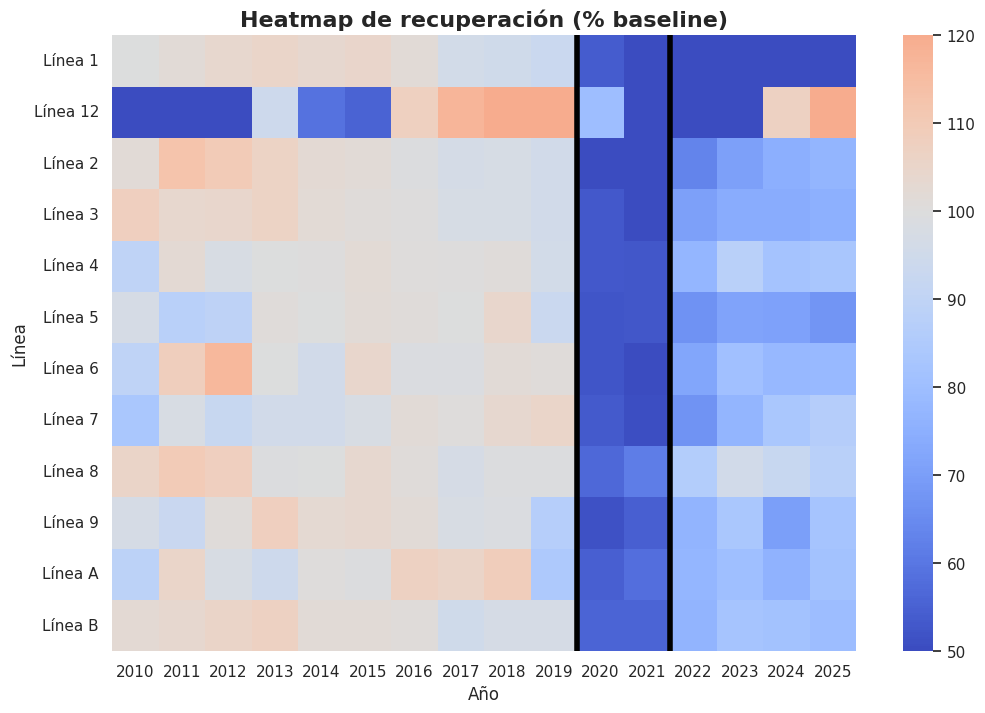

In [39]:
baseline = (
    df[
        (df['anio'] >= 2013) &
        (df['anio'] <= 2019)
    ]
    .groupby('linea')['afluencia']
    .mean()
)
df['baseline_linea'] = df['linea'].map(baseline)

df['pct_baseline'] = (
    df['afluencia'] / df['baseline_linea']*100
)
pivot = df.pivot_table(
    index='linea',
    columns='anio',
    values='pct_baseline'
)
plt.figure(figsize=(12,8))
sns.heatmap(
    pivot,
    center=100,
    cmap='coolwarm',
    vmin=50,
    vmax=120
)
plt.axvline(10, color='black',linewidth=4)
plt.axvline(12, color='black',linewidth=4)
plt.xlabel('Año')
plt.ylabel('Línea')
plt.title('Heatmap de recuperación (% baseline)',fontsize=16,fontweight='bold')
plt.show()

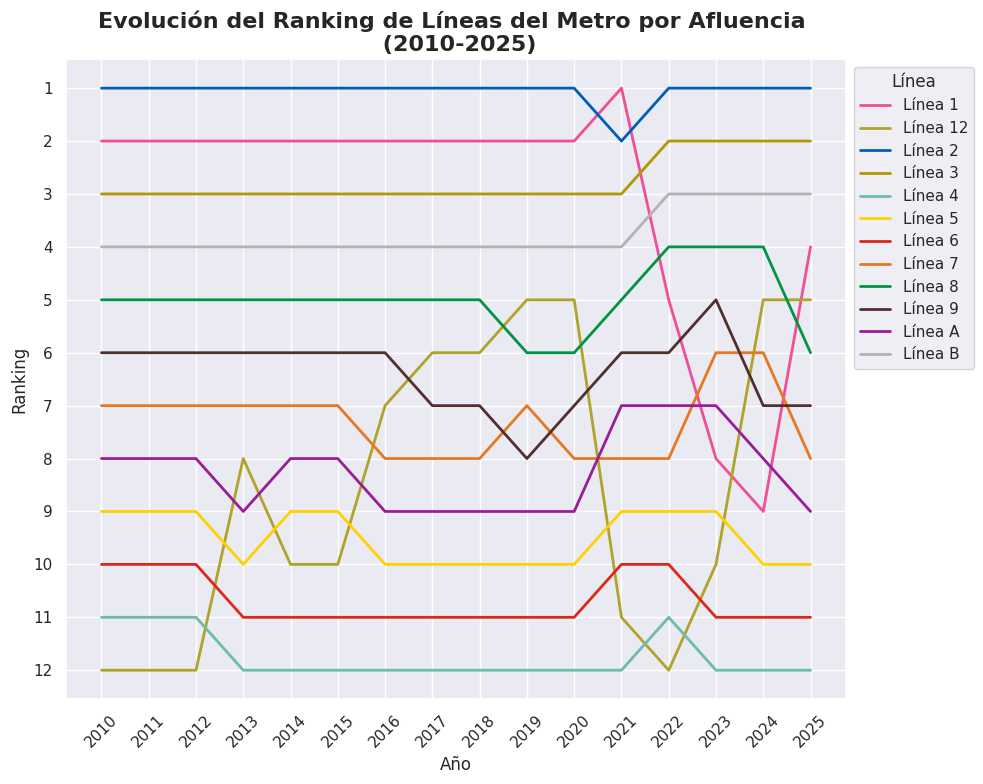

In [71]:
# DataFrame de Afluencia Total por Línea a través de los años
df_rank = (
    df.groupby(['anio','linea'])['afluencia']
    .sum()
    .reset_index()
)

# Columna de Ranking por Línea a través de los años
df_rank['rank'] = (
    df_rank.groupby('anio')['afluencia']
    .rank(ascending=False)
)

# Visualización
plt.figure(figsize=(10,8))
sns.lineplot(
    data=df_rank,
    x='anio',
    y='rank',
    hue='linea',
    palette=colores_metro,
    linewidth=2
)

plt.gca().invert_yaxis()
plt.xticks(sorted(df_rank['anio'].unique()),rotation=45)
plt.yticks(sorted(df_rank['rank'].unique()))
plt.ylabel('Ranking')
plt.xlabel('Año')
plt.title('Evolución del Ranking de Líneas del Metro por Afluencia \n (2010-2025)',fontsize=16,
          fontweight='bold')
plt.legend(
    title='Línea',
    bbox_to_anchor=(1, 1),
    loc='upper left'
)
plt.tight_layout()
plt.show()